# Statistical POS-Tagged Parser using the Penn Treebank

This notebook builds a statistical POS tagger and a PCFG parser from the NLTK Penn Treebank, then evaluates them on 150 sentences collected from the Daily Mirror online newspaper.

## 1. Setup and Corpus Loading

This section imports the required libraries, loads the Penn Treebank corpus, and reports basic statistics about it.

### 1.1 Import Libraries

[ Write your explanation here ]

In [1]:
import nltk
from nltk.corpus import treebank
from collections import Counter

# download the corpus the first time only
try:
    nltk.data.find("corpora/treebank")
except LookupError:
    nltk.download("treebank")

### 1.2 Load the NLTK Penn Treebank (Labeled)

Load the corpus in two forms:
- tagged word/tag pairs for the tagger.
- parsed trees for the PCFG parser.

In [2]:
tagged_sents = treebank.tagged_sents()   # for the TAGGER  (word/tag pairs)
parsed_sents = treebank.parsed_sents()   # for the PARSER  (structure trees)

print("First tagged sentence (first 6 tokens):")
print(tagged_sents[0][:6])

First tagged sentence (first 6 tokens):
[('Pierre', 'NNP'), ('Vinken', 'NNP'), (',', ','), ('61', 'CD'), ('years', 'NNS'), ('old', 'JJ')]


Visualize the structure (tree form) of the first sentence

In [3]:
parsed_sents[0].pretty_print()

                                                     S                                                                         
                         ____________________________|_______________________________________________________________________   
                        |                                               VP                                                   | 
                        |                        _______________________|___                                                 |  
                      NP-SBJ                    |                           VP                                               | 
         _______________|___________________    |     ______________________|______________________________________          |  
        |          |              ADJP      |   |    |        |                PP-CLR                              |         | 
        |          |           ____|____    |   |    |        |          ________|_________          

### 1.3 Corpus Statistics

Compute basic statistics (sentences, tokens, distinct words and tags) to understand the training data. The small size (~3,900 sentences) is relevant to unknown-word errors discussed later.

In [4]:
n_sents  = len(tagged_sents)
tokens   = [tok for s in tagged_sents for tok in s]
n_tokens = len(tokens)
tagset   = {t for _, t in tokens}
vocab    = {w.lower() for w, _ in tokens}

print(f"Sentences            : {n_sents}")
print(f"Tokens (words)       : {n_tokens}")
print(f"Distinct word types  : {len(vocab)}")
print(f"Distinct POS tags    : {len(tagset)}")
print(f"Avg sentence length  : {n_tokens/n_sents:.1f} words")

Sentences            : 3914
Tokens (words)       : 100676
Distinct word types  : 11387
Distinct POS tags    : 46
Avg sentence length  : 25.7 words


## 2. Training the Statistical POS Tagger (HMM)

This section trains the HMM tagger by building its two probability tables from the corpus: transition probabilities (grammar flow) and emission probabilities (word–tag association). These tables are the tagger's learned knowledge, used later with the Viterbi algorithm.

### 2.1 Transition Probabilities

Bigram tag-to-tag transition counts are tallied across the corpus and normalized by maximum likelihood estimation into conditional probabilities P(tag | previous tag), capturing the sequential syntactic dependencies between adjacent tags.

In [5]:
from collections import defaultdict

# count how often each tag follows the previous tag
transition_counts = defaultdict(Counter)   # transition_counts[prev][curr] = count
tag_unigram = Counter()                     # how often each tag occurs overall

for sent in tagged_sents:
    prev = "<s>"                            # sentence-start marker
    for word, tag in sent:
        transition_counts[prev][tag] += 1
        tag_unigram[tag] += 1
        prev = tag

# turn counts into probabilities:  P(curr | prev) = count(prev, curr) / count(prev)
transition_prob = defaultdict(dict)
for prev, nexts in transition_counts.items():
    total = sum(nexts.values())
    for curr, c in nexts.items():
        transition_prob[prev][curr] = c / total

# sanity check: what most commonly follows a determiner (DT)?
print("Most likely tags after DT:")
for tag, p in sorted(transition_prob["DT"].items(), key=lambda x: -x[1])[:5]:
    print(f"  P({tag:4} | DT) = {p:.3f}")

Most likely tags after DT:
  P(NN   | DT) = 0.471
  P(JJ   | DT) = 0.203
  P(NNP  | DT) = 0.129
  P(NNS  | DT) = 0.077
  P(CD   | DT) = 0.023


Transition table

In [6]:
# Understanding the transition table: how grammar "flows"
print("Table size:")
print(f"  {len(transition_prob)} 'previous-tag' rows (each row is a full probability distribution)\n")

# look at several different previous-tags to see the grammar patterns
for prev in ["<s>", "DT", "JJ", "IN", "MD"]:
    top = sorted(transition_prob[prev].items(), key=lambda x: -x[1])[:3]
    shown = ", ".join(f"{tag} ({p:.2f})" for tag, p in top)
    print(f"After {prev:4} -> {shown}")

Table size:
  47 'previous-tag' rows (each row is a full probability distribution)

After <s>  -> DT (0.23), NNP (0.20), IN (0.13)
After DT   -> NN (0.47), JJ (0.20), NNP (0.13)
After JJ   -> NN (0.45), NNS (0.24), JJ (0.06)
After IN   -> DT (0.32), NNP (0.15), NN (0.11)
After MD   -> VB (0.82), RB (0.16), -NONE- (0.01)


### 2.2 Emission Probabilities

Tag-conditioned lexical frequencies are computed from the tagged corpus and normalized via maximum likelihood estimation into emission probabilities P(word | tag), quantifying the lexical generation likelihood of each observation given its category.

In [7]:
# count how often each tag produces each word
emission_counts = defaultdict(Counter)      # emission_counts[tag][word] = count

for sent in tagged_sents:
    for word, tag in sent:
        emission_counts[tag][word.lower()] += 1

# turn counts into probabilities:  P(word | tag) = count(tag, word) / count(tag)
emission_prob = defaultdict(dict)
for tag, words in emission_counts.items():
    total = sum(words.values())
    for word, c in words.items():
        emission_prob[tag][word] = c / total

# sanity check: the most likely words for a singular noun (NN)
print("Most likely words for NN:")
for word, p in sorted(emission_prob["NN"].items(), key=lambda x: -x[1])[:5]:
    print(f"  P({word!r:12} | NN) = {p:.4f}")

Most likely words for NN:
  P('%'          | NN) = 0.0338
  P('company'    | NN) = 0.0197
  P('year'       | NN) = 0.0163
  P('market'     | NN) = 0.0135
  P('trading'    | NN) = 0.0112


Emission table

In [8]:
# Understanding the emission table: which words belong to which tag
print("Table size:")
print(f"  {len(emission_prob)} tag rows; e.g. NN holds {len(emission_prob['NN'])} distinct words\n")

# top words for several different tags
for tag in ["NN", "VBD", "JJ", "IN", "PRP"]:
    top = sorted(emission_prob[tag].items(), key=lambda x: -x[1])[:4]
    shown = ", ".join(f"{w} ({p:.3f})" for w, p in top)
    print(f"{tag:4} -> {shown}")

Table size:
  46 tag rows; e.g. NN holds 2506 distinct words

NN   -> % (0.034), company (0.020), year (0.016), market (0.014)
VBD  -> said (0.202), was (0.121), were (0.065), had (0.053)
JJ   -> new (0.029), other (0.024), last (0.017), many (0.017)
IN   -> of (0.236), in (0.177), for (0.086), that (0.052)
PRP  -> it (0.336), he (0.177), they (0.153), i (0.066)


### 2.3 Smoothing and Unknown-Word Handling

Add-one smoothing is applied to eliminate zero probabilities, and out-of-vocabulary words are handled using a data-driven suffix model with orthographic cues, toggleable via a switch.

**Precompute totals + vocabulary + the switch**

Per-tag totals and the training vocabulary are precomputed for efficiency, and a boolean switch (USE_CLUES) is defined to toggle the unknown-word mechanism for controlled comparison.

In [9]:
import math

# SWITCH: turn the smart unknown-word clue mechanism ON or OFF
USE_CLUES = True     # True = learned suffix + digit + capitalization clues
                     # False = plain uniform fallback (basic baseline)

# precompute totals once (for speed)
all_tags = list(tag_unigram.keys())
num_tags = len(all_tags)
transition_totals = {p: sum(c.values()) for p, c in transition_counts.items()}
emission_totals   = {t: sum(c.values()) for t, c in emission_counts.items()}

# vocabulary + word frequencies (to detect unknown/rare words)
known_words = set()
word_freq   = Counter()
for sent in tagged_sents:
    for word, tag in sent:
        known_words.add(word.lower())
        word_freq[word.lower()] += 1
V = len(known_words)

print("Vocabulary size:", V, "| tags:", num_tags)

Vocabulary size: 11387 | tags: 46


**Learn the suffix --> tag patterns (unknown-word model)**

A suffix-to-tag distribution is learned from low-frequency training words to infer the likely categories of unseen words from their endings.

In [10]:
# LEARN suffix -> tag patterns from RARE words (proxies for unknowns)
MAX_SUFFIX, RARE = 3, 2
suffix_tag_counts = defaultdict(Counter)
for sent in tagged_sents:
    for word, tag in sent:
        wl = word.lower()
        if word_freq[wl] <= RARE:                      # rare words behave like unknowns
            for k in range(1, MAX_SUFFIX + 1):
                if len(wl) >= k:
                    suffix_tag_counts[wl[-k:]][tag] += 1

def suffix_scores(word):
    """Learned tag distribution for a word's ending (backing off 3->2->1 chars)."""
    wl = word.lower()
    for k in range(MAX_SUFFIX, 0, -1):
        if wl[-k:] in suffix_tag_counts:
            c = suffix_tag_counts[wl[-k:]]
            tot = sum(c.values())
            return {tg: n / tot for tg, n in c.items()}
    return None

print("Suffix patterns learned:", len(suffix_tag_counts))

Suffix patterns learned: 2311


**The smoothed probability lookups**

Add-one smoothing is applied to the transition and emission lookups; unknown words are scored by the learned clues or, when disabled, by a uniform fallback.

In [11]:
FLOOR = 1e-8

# smoothed transition probability
def get_transition(prev, curr):
    counts = transition_counts.get(prev, {})
    total  = transition_totals.get(prev, 0)
    return (counts.get(curr, 0) + 1) / (total + num_tags)

# smoothed emission, with clues for unknown words
def get_emission(word, tag):
    wl = word.lower()
    if wl in known_words:                              # seen in training -> smoothed count
        return (emission_counts[tag].get(wl, 0) + 1) / (emission_totals.get(tag, 0) + V)

    # unknown word
    if not USE_CLUES:
        return 1.0 / (emission_totals.get(tag, 0) + V)   # plain uniform fallback

    dist  = suffix_scores(word)                          # learned suffix distribution
    score = (1.0 / num_tags) if dist is None else dist.get(tag, 0.0)
    if any(ch.isdigit() for ch in word):                 # digit -> number
        score = 0.9 if tag == "CD" else score * 0.1
    if word[0].isupper() and tag in ("NNP", "NNPS"):     # capital -> proper noun
        score += 0.5
    return max(score, FLOOR)

print("Smoothed lookups ready.")

Smoothed lookups ready.


### 2.4 Viterbi Decoding
The Viterbi algorithm is implemented in log-space to decode the most probable tag sequence using dynamic programming with back-pointers.

In [12]:
def viterbi(sentence):
    """sentence: list of word strings. Returns list of (word, tag)."""
    if not sentence:
        return []
    Vt = [{}]; bp = [{}]                                 # scores + back-pointers

    # first word: transition from the <s> start marker
    for tag in all_tags:
        Vt[0][tag] = math.log(get_transition("<s>", tag)) + math.log(get_emission(sentence[0], tag))
        bp[0][tag] = "<s>"

    # remaining words
    for i in range(1, len(sentence)):
        Vt.append({}); bp.append({})
        for tag in all_tags:
            best_prev, best = None, float("-inf")
            for pt in all_tags:                          # best way to reach `tag`
                s = Vt[i-1][pt] + math.log(get_transition(pt, tag))
                if s > best:
                    best, best_prev = s, pt
            Vt[i][tag] = best + math.log(get_emission(sentence[i], tag))
            bp[i][tag] = best_prev

    # trace back the winning path
    last = max(Vt[-1], key=Vt[-1].get)
    tags = [last]
    for i in range(len(sentence) - 1, 0, -1):
        last = bp[i][last]
        tags.insert(0, last)
    return list(zip(sentence, tags))

# test the finished tagger
for s in ["The winning team wowed in the stadium",
          "Officials announced a new economic policy"]:
    print(s)
    for word, tag in viterbi(s.split()):
        print(f"   {word:12} -> {tag}")
    print()

The winning team wowed in the stadium
   The          -> DT
   winning      -> JJ
   team         -> NN
   wowed        -> VBD
   in           -> IN
   the          -> DT
   stadium      -> NN

Officials announced a new economic policy
   Officials    -> NNS
   announced    -> VBD
   a            -> DT
   new          -> JJ
   economic     -> JJ
   policy       -> NN



### 2.5 Effect of the clue mechanism
A controlled comparison illustrates the effect of the unknown-word clue mechanism on the tags assigned to unseen words.

In [13]:
# --- compare tagging WITH vs WITHOUT the clue mechanism ---
test = "Colombo hosted a thrilling cricketing festival".split()

USE_CLUES = False
off = viterbi(test)
USE_CLUES = True
on  = viterbi(test)

print(f"{'word':12} {'CLUES OFF':10} {'CLUES ON':10}")
print("-" * 34)
for (w, t_off), (_, t_on) in zip(off, on):
    mark = "" if t_off == t_on else "  <-- changed"
    print(f"{w:12} {t_off:10} {t_on:10}{mark}")

USE_CLUES = True   # leave it ON for the rest of the notebook

word         CLUES OFF  CLUES ON  
----------------------------------
Colombo      PRP        NNP         <-- changed
hosted       VBD        ,           <-- changed
a            DT         DT        
thrilling    NN         JJ          <-- changed
cricketing   .          NN          <-- changed
festival     ''         NN          <-- changed


### 2.6 Save the trained tagger to disk

The trained tagger's learned parameters are serialized to disk so the model can be reused without retraining and submitted as a deliverable.

**Save the tagger**

The transition and emission counts, vocabulary, word frequencies, and learned suffix patterns are bundled and serialized to models/hmm_tagger.pkl using pickle.

In [14]:
import pickle, os

os.makedirs("models", exist_ok=True)   # make the models/ folder if needed

# bundle everything the tagger needs into one dictionary
tagger_model = {
    "transition_counts": {p: dict(c) for p, c in transition_counts.items()},
    "emission_counts":   {t: dict(c) for t, c in emission_counts.items()},
    "tag_unigram":       dict(tag_unigram),
    "known_words":       known_words,
    "word_freq":         dict(word_freq),
    "suffix_tag_counts": {s: dict(c) for s, c in suffix_tag_counts.items()},
}

with open("models/hmm_tagger.pkl", "wb") as f:
    pickle.dump(tagger_model, f)

print("Saved -> models/hmm_tagger.pkl")
print("File size:", round(os.path.getsize("models/hmm_tagger.pkl")/1024, 1), "KB")

Saved -> models/hmm_tagger.pkl
File size: 464.6 KB


**Verify it reloads**

The serialized model is reloaded and its contents verified to confirm the save is complete and intact.

In [15]:
# reload and confirm the saved model works
with open("models/hmm_tagger.pkl", "rb") as f:
    loaded = pickle.load(f)

print("Reloaded successfully.")
print("  tags saved      :", len(loaded["tag_unigram"]))
print("  vocabulary saved:", len(loaded["known_words"]))
print("  suffix patterns :", len(loaded["suffix_tag_counts"]))

Reloaded successfully.
  tags saved      : 46
  vocabulary saved: 11387
  suffix patterns : 2311


## 3. Building the PCFG Parser

A probabilistic context-free grammar is induced from the treebank's parsed trees by extracting, counting, and normalizing production rules.

### 3.1 Extract Productions from the Parsed Trees

The production rules composing an individual parse tree are displayed to illustrate that a tree is a composition of grammar rules.

In [16]:
# every tree is made of production rules — let's see them for one sentence
sample_tree = parsed_sents[0]
print("Productions in the first tree (first 8):")
for prod in sample_tree.productions()[:8]:
    print("  ", prod)

Productions in the first tree (first 8):
   S -> NP-SBJ VP .
   NP-SBJ -> NP , ADJP ,
   NP -> NNP NNP
   NNP -> 'Pierre'
   NNP -> 'Vinken'
   , -> ','
   ADJP -> NP JJ
   NP -> CD NNS


### 3.2 Convert Trees to Chomsky Normal Form

Each parse tree is converted to Chomsky Normal Form so that all productions are binary, satisfying the requirement of the CKY parsing algorithm.

In [17]:
from nltk import Tree

cnf_trees = []
for tree in parsed_sents:
    t = tree.copy(deep=True)          # don't modify the original
    t.collapse_unary(collapsePOS=True)  # tidy single-child chains
    t.chomsky_normal_form()           # make every rule binary (<=2 children)
    cnf_trees.append(t)

print("Converted", len(cnf_trees), "trees to CNF.")
print("\nExample CNF rules (first 8 of tree 0):")
for prod in cnf_trees[0].productions()[:8]:
    print("  ", prod)

Converted 3914 trees to CNF.

Example CNF rules (first 8 of tree 0):
   S -> NP-SBJ S|<VP-.>
   NP-SBJ -> NP NP-SBJ|<,-ADJP-,>
   NP -> NNP NNP
   NNP -> 'Pierre'
   NNP -> 'Vinken'
   NP-SBJ|<,-ADJP-,> -> , NP-SBJ|<ADJP-,>
   , -> ','
   NP-SBJ|<ADJP-,> -> ADJP ,


### 3.3 Induce the PCFG

The PCFG is induced via maximum likelihood estimation, counting each production and normalizing so that the rules for each non-terminal sum to one.

In [18]:
from nltk import induce_pcfg, Nonterminal

# collect every production from every CNF tree
all_productions = []
for t in cnf_trees:
    all_productions += t.productions()

# induce the PCFG: counts each rule and normalizes to probabilities
pcfg_grammar = induce_pcfg(Nonterminal("S"), all_productions)

print("Total production rules in grammar:", len(pcfg_grammar.productions()))
print("\nMost frequent phrase rules (highest probability first):")
ranked = sorted(pcfg_grammar.productions(), key=lambda p: p.prob(), reverse=True)
for p in [r for r in ranked if len(r.rhs()) == 2][:8]:
    print(f"   {str(p.lhs()):6} -> {' '.join(map(str, p.rhs())):22} p={p.prob():.3f}")

Total production rules in grammar: 32313

Most frequent phrase rules (highest probability first):
   NP-SBJ|<,-ADJP-,> -> , NP-SBJ|<ADJP-,>      p=1.000
   NP-SBJ|<ADJP-,> -> ADJP ,                 p=1.000
   S|<VP-.> -> VP .                   p=1.000
   VP|<NP-PP-CLR-NP-TMP> -> NP VP|<PP-CLR-NP-TMP>  p=1.000
   VP|<PP-CLR-NP-TMP> -> PP-CLR NP-TMP          p=1.000
   NP|<JJ-NN> -> JJ NN                  p=1.000
   NP|<,-NP> -> , NP                   p=1.000
   NP|<NNP-VBG-NN> -> NNP NP|<VBG-NN>        p=1.000


### 3.4 Save the PCFG Parser Data

The induced PCFG is serialized to models/pcfg_grammar.txt, with each production and its probability recorded; this file constitutes the required PCFG parser data.

In [19]:
import os
os.makedirs("models", exist_ok=True)

# write every rule with its probability to a text file
with open("models/pcfg_grammar.txt", "w", encoding="utf-8") as f:
    f.write(f"# PCFG induced from the NLTK Penn Treebank\n")
    f.write(f"# Start symbol: {pcfg_grammar.start()}\n")
    f.write(f"# Total rules: {len(pcfg_grammar.productions())}\n\n")
    for prod in pcfg_grammar.productions():
        f.write(f"{prod}\n")

print("Saved -> models/pcfg_grammar.txt")
print("Total rules written:", len(pcfg_grammar.productions()))
print("File size:", round(os.path.getsize("models/pcfg_grammar.txt")/1024, 1), "KB")

Saved -> models/pcfg_grammar.txt
Total rules written: 32313
File size: 1219.6 KB


### 3.5 Parsing Sanity Check

A Viterbi (CKY-based) parser is instantiated from the grammar and applied to a sample sentence to recover its most probable parse tree, which is converted out of Chomsky Normal Form for readability.

In [20]:
from nltk.parse import ViterbiParser

parser = ViterbiParser(pcfg_grammar)

sentence = "the board approved the plan".split()

print("Parsing:", " ".join(sentence), "\n")
found = False
for tree in parser.parse(sentence):
    found = True
    tree.un_chomsky_normal_form()      # fold helper nodes back into a natural tree
    print("Most probable parse (probability = {:.3e}):\n".format(tree.prob()))
    tree.pretty_print()

if not found:
    print("No parse found — the grammar doesn't cover this exact sentence.")

Parsing: the board approved the plan 

Most probable parse (probability = 5.065e-13):

                    S                 
       _____________|______            
      |                    VP         
      |              ______|___        
    NP-SBJ          |          NP     
  ____|______       |       ___|___    
 DT          NN    VBD     DT      NN 
 |           |      |      |       |   
the        board approved the     plan



## 4. Preparing the 150 Daily Mirror Sentences

The 150 collected sentences are loaded with their section labels and tokenized using Penn Treebank conventions to ensure consistency with the training corpus, then written as a template for manual annotation.

### 4.1 Load the Raw Sentences

The raw sentences are read from file, preserving the section (business, politics, sport, local) each belongs to for later per-topic analysis.

In [21]:
# read the raw sentences, keeping track of which section each belongs to
raw_path = "data/daily_mirror_raw.txt"

sentences = []          # list of (section, sentence_text)
current_section = "unknown"
with open(raw_path, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith("#"):
            current_section = line.lstrip("# ").strip()
        else:
            sentences.append((current_section, line))

print("Loaded", len(sentences), "sentences")
from collections import Counter
print("By section:", dict(Counter(s for s, _ in sentences)))

Loaded 150 sentences
By section: {'business': 40, 'politics': 40, 'sport': 40, 'local': 30}


### 4.2 Penn Treebank Tokenization

Each sentence is tokenized with NLTK's TreebankWordTokenizer so that punctuation and contractions match the training data, and a tab-separated template is generated for manual POS annotation.

In [22]:
from nltk.tokenize import TreebankWordTokenizer

tokenizer = TreebankWordTokenizer()

# tokenize every sentence
tokenized = []          # list of (section, [tokens])
for section, text in sentences:
    tokens = tokenizer.tokenize(text)
    tokenized.append((section, tokens))

total_tokens = sum(len(toks) for _, toks in tokenized)
print("Total tokens across all sentences:", total_tokens)
print("\nExample — first sentence tokenized:")
print(tokenized[0][1])

# write a tagging template: one "word<TAB>" per line, blank line between sentences
with open("data/daily_mirror_template.txt", "w", encoding="utf-8") as f:
    for i, (section, tokens) in enumerate(tokenized):
        f.write(f"# sentence {i+1} [{section}]\n")
        for tok in tokens:
            f.write(f"{tok}\t\n")      # word, a TAB, then blank for you to add the tag
        f.write("\n")                 # blank line separates sentences

print("\nTemplate written -> data/daily_mirror_template.txt")

Total tokens across all sentences: 2451

Example — first sentence tokenized:
['The', 'session', 'was', 'well', 'received', 'by', 'participants', ',', 'who', 'engaged', 'actively', 'with', 'the', 'themes', 'discussed', '.']

Template written -> data/daily_mirror_template.txt


### 4.3 Load the Gold-Standard Tags

The annotated file is parsed into sentences of (word, gold-tag) pairs, preserving each sentence's section for later per-topic analysis.

In [23]:
GOLD_FILE = "data/daily_mirror_tagged.txt"   # <-- match your actual filename

gold_sentences = []      # list of (section, [(word, gold_tag), ...])
current_section = "unknown"
current = []

with open(GOLD_FILE, encoding="utf-8") as f:
    for raw in f:
        line = raw.replace("\r", "").rstrip("\n")
        if line.strip() == "":
            continue
        if line.lstrip().startswith("#"):
            if current:
                gold_sentences.append((current_section, current))
                current = []
            if "[" in line and "]" in line:
                current_section = line[line.index("[")+1:line.index("]")]
        else:
            word, tag = line.split()
            current.append((word, tag))
    if current:
        gold_sentences.append((current_section, current))

print("Loaded", len(gold_sentences), "gold sentences")
print("Total tokens:", sum(len(s) for _, s in gold_sentences))
print("\nExample (sentence 1, first 5 tokens):")
print(gold_sentences[0][1][:5])

Loaded 150 gold sentences
Total tokens: 2451

Example (sentence 1, first 5 tokens):
[('The', 'DT'), ('session', 'NN'), ('was', 'VBD'), ('well', 'RB'), ('received', 'VBN')]


## 5. Tagging and Parsing the 150 Sentences

The trained tagger is applied to the 150 annotated sentences to produce predictions, which are then evaluated against the gold standard in the following section.

### 5.1 Tag with the Trained Model

The Viterbi tagger is applied to each sentence, and predictions are aligned with the gold tags into (word, gold, predicted) triples; a length check confirms exact alignment.

In [24]:
USE_CLUES = True

predictions = []     # list of (section, [(word, gold_tag, pred_tag), ...])

for section, tagged in gold_sentences:
    words = [w for w, t in tagged]
    pred = viterbi(words)
    combined = [(w, gold_t, pred_t)
                for (w, gold_t), (_, pred_t) in zip(tagged, pred)]
    predictions.append((section, combined))

mismatch = sum(1 for (s, tagged), (s2, comb) in zip(gold_sentences, predictions)
               if len(tagged) != len(comb))
print("Sentences with length mismatch:", mismatch, "(should be 0)")
print("\nExample — sentence 1 (word / gold / predicted):")
for w, g, p in predictions[0][1][:8]:
    mark = "" if g == p else "  <-- differs"
    print(f"  {w:14} {g:5} {p:5}{mark}")

Sentences with length mismatch: 0 (should be 0)

Example — sentence 1 (word / gold / predicted):
  The            DT    DT   
  session        NN    NN   
  was            VBD   VBD  
  well           RB    RB   
  received       VBN   VBN  
  by             IN    IN   
  participants   NNS   NNS  
  ,              ,     ,    


### 5.2 Parse a Sample of Sentences

A sample of short sentences is parsed with the PCFG-based Viterbi parser to demonstrate constituency parsing; longer or unseen structures may not be covered by the induced grammar.

In [26]:
from nltk.parse import ViterbiParser

parser = ViterbiParser(pcfg_grammar)

# try to parse a few short sentences from the 150 (long ones often won't parse)
sample_indices = [73, 40, 148]   # short sentences; adjust if needed
parsed_count = 0

for idx in sample_indices:
    words = [w for w, t in gold_sentences[idx][1]]
    print("Sentence:", " ".join(words))
    try:
        trees = list(parser.parse(words))
        if trees:
            trees[0].un_chomsky_normal_form()
            print(f"  Parsed (prob={trees[0].prob():.2e})")
            trees[0].pretty_print()
            parsed_count += 1
        else:
            print("  No parse found (structure not covered by grammar).")
    except Exception as e:
        print("  No parse found (word not in grammar).")
    print()

print(f"Parsed {parsed_count}/{len(sample_indices)} sample sentences.")

Sentence: Transport is the third priority .
  No parse found (word not in grammar).

Sentence: The White House rejected the findings .
  Parsed (prob=1.06e-18)
                    S                         
       _____________|_______________________   
      |                    VP               | 
      |              ______|___             |  
    NP-SBJ          |          NP           | 
  ____|______       |       ___|_____       |  
 DT  NNP    NNP    VBD     DT       NNS     . 
 |    |      |      |      |         |      |  
The White  House rejected the     findings  . 


Sentence: Iran did not return the aircraft .
  No parse found (word not in grammar).

Parsed 1/3 sample sentences.


### 5.3 Save the Predictions

The tagger's predictions are saved alongside the gold tags to results/predictions.txt as a record of model output.

In [27]:
import os
os.makedirs("results", exist_ok=True)

with open("results/predictions.txt", "w", encoding="utf-8") as f:
    for i, (section, comb) in enumerate(predictions):
        f.write(f"# sentence {i+1} [{section}]\n")
        for w, gold, pred in comb:
            f.write(f"{w}\t{gold}\t{pred}\n")
        f.write("\n")

print("Predictions saved -> results/predictions.txt")

Predictions saved -> results/predictions.txt


## 6. Evaluation

This section evaluates the POS tagger against the manually annotated gold standard using standard performance metrics. It reports overall accuracy, compares three model configurations (baseline, HMM without unknown-word clues, and the full model), disaggregates accuracy by news section, and presents per-tag precision, recall and F1 along with a confusion matrix and out-of-vocabulary analysis.

### 6.1 Overall Accuracy

The overall tagging accuracy of the full model is computed against the gold standard as the proportion of correctly tagged tokens.

In [31]:
correct = total = 0
for section, comb in predictions:
    for w, gold, pred in comb:
        total += 1
        if gold == pred:
            correct += 1
accuracy = correct / total
print(f"Overall tagging accuracy : {accuracy:.4f}  ({correct}/{total})")

Overall tagging accuracy : 0.8352  (2047/2451)


#### **Overall Accuracy of the model is 83.52%**

### 6.2 Model Compariso

Three configurations are compared to isolate the contribution of each component: a most-frequent-tag baseline (no context), the HMM with contextual Viterbi decoding but no unknown-word handling (clues off), and the full model with the data-driven unknown-word mechanism (clues on).

In [32]:
from collections import defaultdict, Counter

# --- baseline: most-frequent training tag per word ---
word_tag_counts = defaultdict(Counter)
for tag, wc in emission_counts.items():
    for w, c in wc.items():
        word_tag_counts[w][tag] += c
overall_most_common = tag_unigram.most_common(1)[0][0]

def baseline_tag(word):
    w = word.lower()
    if w in word_tag_counts:
        return word_tag_counts[w].most_common(1)[0][0]
    return overall_most_common

def evaluate_accuracy():
    corr = tot = 0
    for section, tagged in gold_sentences:
        words = [w for w, t in tagged]
        pred = viterbi(words)
        for (w, gold), (_, p) in zip(tagged, pred):
            tot += 1
            if gold == p:
                corr += 1
    return corr / tot

# baseline
base_correct = sum(1 for _, comb in predictions for w, gold, pred in comb
                   if baseline_tag(w) == gold)
baseline_acc = base_correct / total

# clues OFF
USE_CLUES = False
acc_off = evaluate_accuracy()

# clues ON (full model)
USE_CLUES = True
acc_on = evaluate_accuracy()

print(f"{'Configuration':38} {'Accuracy':>9}")
print("-" * 48)
print(f"{'1. Baseline (most-frequent tag)':38} {baseline_acc:>9.4f}")
print(f"{'2. HMM + Viterbi, clues OFF':38} {acc_off:>9.4f}")
print(f"{'3. Full model (clues ON)':38} {acc_on:>9.4f}")
print("-" * 48)
print(f"{'Context gain (1 -> 2)':38} {acc_off - baseline_acc:>+9.4f}")
print(f"{'Unknown-word gain (2 -> 3)':38} {acc_on - acc_off:>+9.4f}")
print(f"{'Total gain (1 -> 3)':38} {acc_on - baseline_acc:>+9.4f}")

USE_CLUES = True   # leave ON for the rest of the notebook

Configuration                           Accuracy
------------------------------------------------
1. Baseline (most-frequent tag)           0.7989
2. HMM + Viterbi, clues OFF               0.7568
3. Full model (clues ON)                  0.8352
------------------------------------------------
Context gain (1 -> 2)                    -0.0420
Unknown-word gain (2 -> 3)               +0.0783
Total gain (1 -> 3)                      +0.0363


### 6.3 Per-Section (Category) Accuracy

Accuracy is disaggregated by news section (business, politics, sport, local) to examine how tagging performance varies with each section's similarity to the training domain.

In [35]:
section_correct = Counter()
section_total = Counter()
for section, comb in predictions:
    for w, gold, pred in comb:
        section_total[section] += 1
        if gold == pred:
            section_correct[section] += 1

print(f"{'Section':10} {'Accuracy':>10} {'Correct/Total':>16}")
print("-" * 38)
for sec in ["business", "politics", "sport", "local"]:
    if section_total[sec]:
        acc = section_correct[sec] / section_total[sec]
        print(f"{sec:10} {acc:>10.4f} {str(section_correct[sec])+'/'+str(section_total[sec]):>16}")

Section      Accuracy    Correct/Total
--------------------------------------
business       0.8291          553/667
politics       0.8413          578/687
sport          0.8478          557/657
local          0.8159          359/440


### 6.4 Per-tag Precision, Recall, F1

Per-tag precision, recall and F1 scores are computed using the gold tags as reference, identifying which grammatical categories are tagged reliably and which are frequently confused.

In [36]:
from sklearn.metrics import classification_report

# flatten all predictions into two aligned lists
y_true = [gold for _, comb in predictions for w, gold, pred in comb]
y_pred = [pred for _, comb in predictions for w, gold, pred in comb]

# per-tag precision / recall / F1
report = classification_report(y_true, y_pred, zero_division=0, digits=3)
print(report)

              precision    recall  f1-score   support

           $      0.000     0.000     0.000         0
          ''      0.000     0.000     0.000         0
           (      0.000     0.000     0.000         2
           )      0.000     0.000     0.000         2
           ,      0.808     1.000     0.894        42
      -NONE-      0.000     0.000     0.000         0
           .      0.968     1.000     0.984       150
           :      0.000     0.000     0.000         2
          CC      1.000     1.000     1.000        54
          CD      0.905     0.927     0.916        41
          DT      0.900     0.993     0.944       282
          FW      0.000     0.000     0.000         2
          IN      0.866     0.892     0.879       260
          JJ      0.714     0.789     0.750       171
         JJR      0.500     0.333     0.400         9
         JJS      1.000     0.143     0.250         7
          MD      0.941     0.914     0.928        35
          NN      0.783    

### 6.5 Confusion Matrix

A confusion matrix of the twelve most frequent tags is presented as a heatmap; the diagonal represents correct predictions and off-diagonal cells reveal systematic misclassifications between grammatical categories.

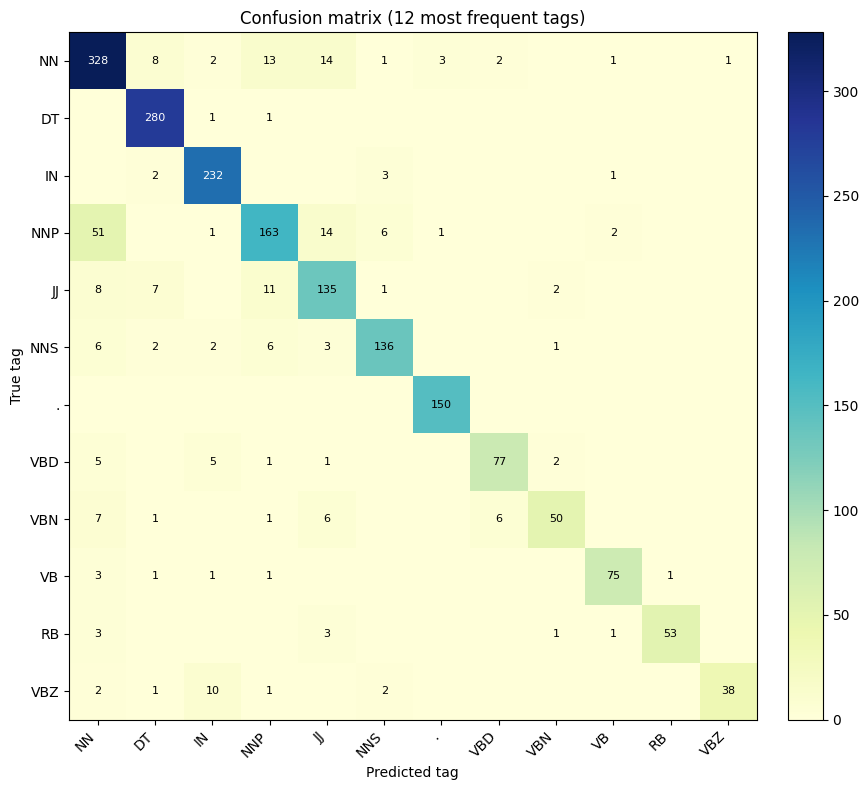

Saved -> results/confusion_matrix.png


In [37]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from sklearn.metrics import confusion_matrix
import os

# focus on the 12 most frequent tags (a full 40+ matrix is unreadable)
top_tags = [t for t, _ in Counter(y_true).most_common(12)]
cm = confusion_matrix(y_true, y_pred, labels=top_tags)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap="YlGnBu")
ax.set_xticks(range(len(top_tags)))
ax.set_yticks(range(len(top_tags)))
ax.set_xticklabels(top_tags, rotation=45, ha="right")
ax.set_yticklabels(top_tags)
ax.set_xlabel("Predicted tag")
ax.set_ylabel("True tag")
ax.set_title("Confusion matrix (12 most frequent tags)")

for i in range(len(top_tags)):
    for j in range(len(top_tags)):
        val = cm[i, j]
        if val > 0:
            color = "white" if val > cm.max() * 0.5 else "black"
            ax.text(j, i, val, ha="center", va="center", color=color, fontsize=8)

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/confusion_matrix.png", dpi=130)
plt.show()
print("Saved -> results/confusion_matrix.png")

### 6.6 Out-Of-Vocabulary (OOV) analysis

The out-of-vocabulary (OOV) rate is measured, and tagging accuracy on unseen words is compared with accuracy on seen words. The most frequent OOV misclassifications and examples are listed to link the accuracy gap to specific out-of-domain vocabulary.

In [38]:
# a word is "known" if it appeared in training (case-insensitive)
def is_known(word):
    return word.lower() in known_words

# split predictions into seen vs unseen, count correct
seen_correct = seen_total = 0
oov_correct = oov_total = 0
oov_words = []

for section, comb in predictions:
    for w, gold, pred in comb:
        if is_known(w):
            seen_total += 1
            if gold == pred:
                seen_correct += 1
        else:
            oov_total += 1
            oov_words.append((w, gold, pred))
            if gold == pred:
                oov_correct += 1

total_tokens = seen_total + oov_total
oov_rate = oov_total / total_tokens

print(f"OOV rate                    : {oov_rate:.4f}  ({oov_total}/{total_tokens} words unseen)")
print(f"Accuracy on SEEN words      : {seen_correct/seen_total:.4f}  ({seen_correct}/{seen_total})")
print(f"Accuracy on UNSEEN (OOV)    : {oov_correct/oov_total:.4f}  ({oov_correct}/{oov_total})")
print(f"Accuracy gap                : {seen_correct/seen_total - oov_correct/oov_total:+.4f}")

# what tags do OOV words most often get wrong?
from collections import Counter
oov_errors = Counter((gold, pred) for w, gold, pred in oov_words if gold != pred)
print("\nMost common OOV mistakes (true -> predicted):")
for (gold, pred), c in oov_errors.most_common(8):
    print(f"  {gold:5} -> {pred:5}  ({c} times)")

# a few example OOV words that were mistagged
print("\nExample mistagged OOV words:")
for w, gold, pred in [x for x in oov_words if x[1] != x[2]][:10]:
    print(f"  {w:16} gold={gold:5} pred={pred}")

OOV rate                    : 0.1371  (336/2451 words unseen)
Accuracy on SEEN words      : 0.8440  (1785/2115)
Accuracy on UNSEEN (OOV)    : 0.7798  (262/336)
Accuracy gap                : +0.0642

Most common OOV mistakes (true -> predicted):
  NNP   -> NN     (11 times)
  NN    -> JJ     (7 times)
  JJ    -> NN     (6 times)
  NN    -> NNP    (6 times)
  JJ    -> NNP    (5 times)
  NNP   -> NNS    (3 times)
  VBN   -> JJ     (3 times)
  NNS   -> NNP    (2 times)

Example mistagged OOV words:
  themes           gold=NNS   pred=NNP
  memoranda        gold=NNS   pred=NN
  rip-and-replace  gold=JJ    pred=NN
  Creatives        gold=NNP   pred=NNS
  Programme        gold=NNP   pred=NN
  comply           gold=VB    pred=RB
  whilst           gold=IN    pred=VB
  towards          gold=IN    pred=NNS
  app              gold=NN    pred=NNP
  Google           gold=NNP   pred=NN


### 6.7 Saving the Evaluation Results

All evaluation metrics such as overall accuracy, the ablation comparison, per-section accuracy, OOV analysis, and per-tag scores, are written to results/metrics.txt as a permanent record of the test results.

In [39]:
import os
os.makedirs("results", exist_ok=True)

with open("results/metrics.txt", "w", encoding="utf-8") as f:
    f.write("POS TAGGER — EVALUATION RESULTS\n")
    f.write("=" * 50 + "\n\n")

    f.write("OVERALL ACCURACY\n")
    f.write(f"  Full model (clues ON) : {acc_on:.4f}  ({correct}/{total})\n\n")

    f.write("MODEL COMPARISON (ABLATION)\n")
    f.write(f"  1. Baseline (most-frequent tag) : {baseline_acc:.4f}\n")
    f.write(f"  2. HMM + Viterbi, clues OFF     : {acc_off:.4f}\n")
    f.write(f"  3. Full model (clues ON)        : {acc_on:.4f}\n")
    f.write(f"  Context gain (1->2)             : {acc_off - baseline_acc:+.4f}\n")
    f.write(f"  Unknown-word gain (2->3)        : {acc_on - acc_off:+.4f}\n")
    f.write(f"  Total gain (1->3)               : {acc_on - baseline_acc:+.4f}\n\n")

    f.write("PER-SECTION ACCURACY\n")
    for s in ["business", "politics", "sport", "local"]:
        acc = section_correct[s] / section_total[s]
        f.write(f"  {s:10}: {acc:.4f}  ({section_correct[s]}/{section_total[s]})\n")
    f.write("\n")

    f.write("OUT-OF-VOCABULARY ANALYSIS\n")
    f.write(f"  OOV rate                : {oov_rate:.4f}  ({oov_total}/{total_tokens})\n")
    f.write(f"  Accuracy on SEEN words  : {seen_correct/seen_total:.4f}\n")
    f.write(f"  Accuracy on OOV words   : {oov_correct/oov_total:.4f}\n")
    f.write(f"  Accuracy gap            : {seen_correct/seen_total - oov_correct/oov_total:+.4f}\n\n")

    f.write("PER-TAG PRECISION / RECALL / F1\n")
    f.write(classification_report(y_true, y_pred, zero_division=0, digits=3))

print("Metrics saved -> results/metrics.txt")

Metrics saved -> results/metrics.txt


## 7. Results Summary and Error Analysis

[ Write your explanation here ]